In [1]:
# imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from pathlib import Path

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# load results

PROJECT_ROOT = Path().resolve().parent
RESULTS_PATH = PROJECT_ROOT / "results" / "experiments.csv"

df = pd.read_csv(RESULTS_PATH)
df

,model_name,accuracy,macro_f1,weighted_f1,akiec_precision,akiec_recall,akiec_f1,akiec_support,bcc_precision,bcc_recall,...,mel_f1,mel_support,nv_precision,nv_recall,nv_f1,nv_support,vasc_precision,vasc_recall,vasc_f1,vasc_support
0,baseline_model,0.837335,0.729056,0.833673,0.678571,0.558824,0.612903,68.0,0.827869,0.765152,...,0.592771,225.0,0.905045,0.937020,0.920755,1302.0,0.767442,0.916667,0.835443,36.0
1,baseline_model_1.5,0.840274,0.733328,0.839539,0.676923,0.647059,0.661654,68.0,0.775362,0.810606,...,0.643172,225.0,0.916283,0.916283,0.916283,1302.0,0.756098,0.861111,0.805195,36.0
2,augmented_model,0.783929,0.694522,0.796678,0.556962,0.647059,0.598639,68.0,0.810345,0.712121,...,0.558730,225.0,0.938380,0.818740,0.874487,1302.0,0.708333,0.944444,0.809524,36.0
3,focal_model,0.635963,0.612738,0.658512,0.519481,0.588235,0.551724,68.0,0.600000,0.863636,...,0.466488,225.0,0.976871,0.551459,0.704958,1302.0,0.516129,0.888889,0.653061,36.0


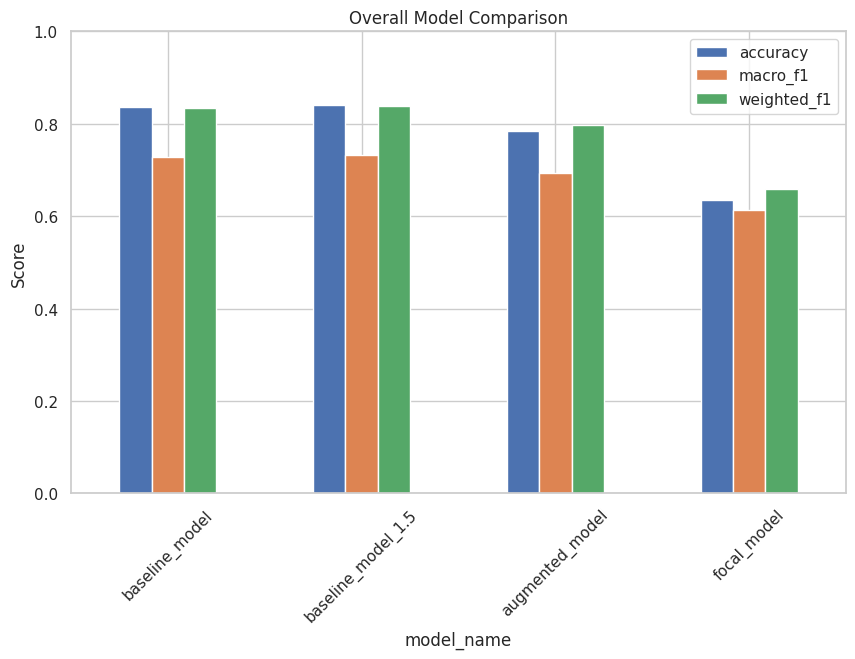

In [3]:
# baseline metric comparison

metrics = df[["model_name", "accuracy", "macro_f1", "weighted_f1"]]

metrics.set_index("model_name").plot(kind="bar")
plt.title("Overall Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

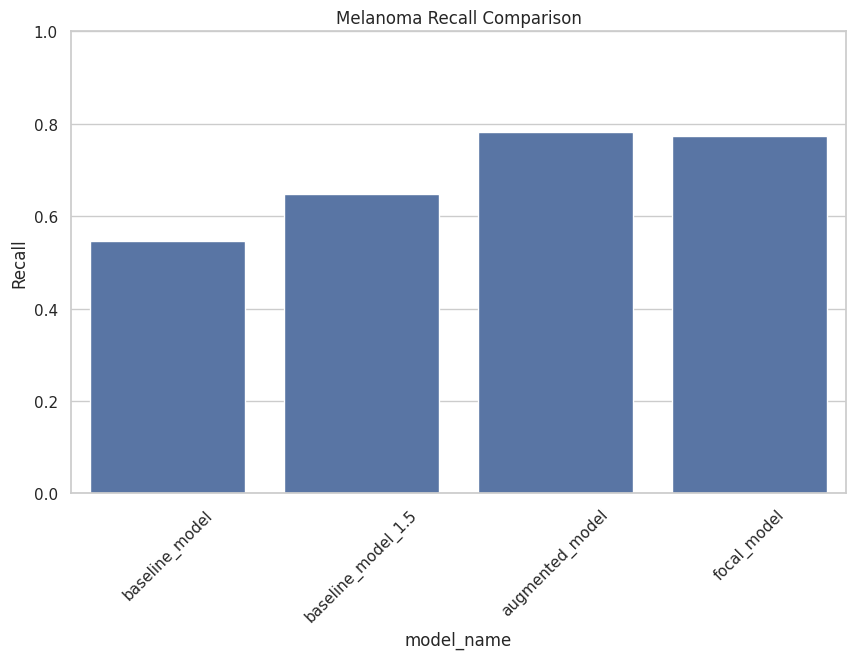

In [4]:
# melanoma recall comparison

mel_recall = df[["model_name", "mel_recall"]]

sns.barplot(data=mel_recall, x="model_name", y="mel_recall")
plt.title("Melanoma Recall Comparison")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

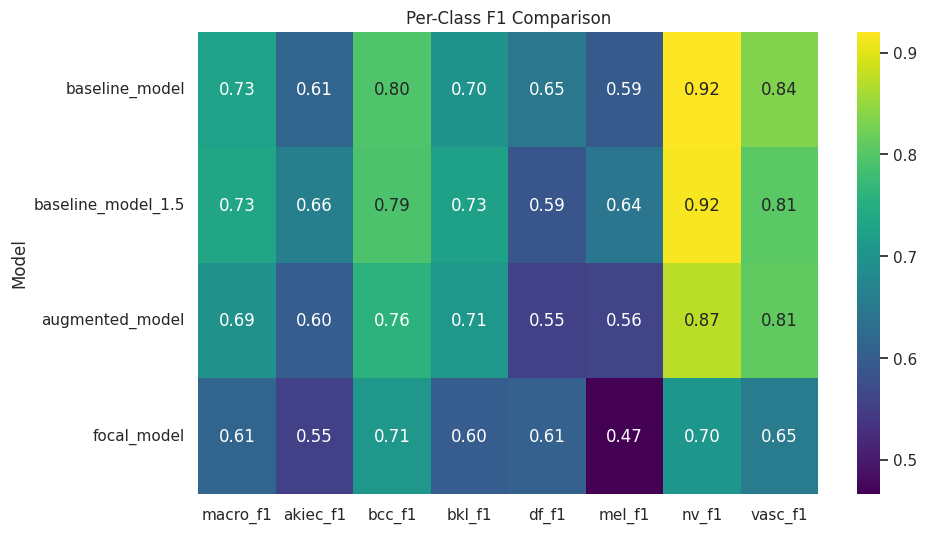

In [5]:
# per class f1 heatmap

class_columns = [col for col in df.columns if col.endswith("_f1") and col != "weighted_f1"]

heatmap_data = df.set_index("model_name")[class_columns]

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Per-Class F1 Comparison")
plt.ylabel("Model")
plt.show()

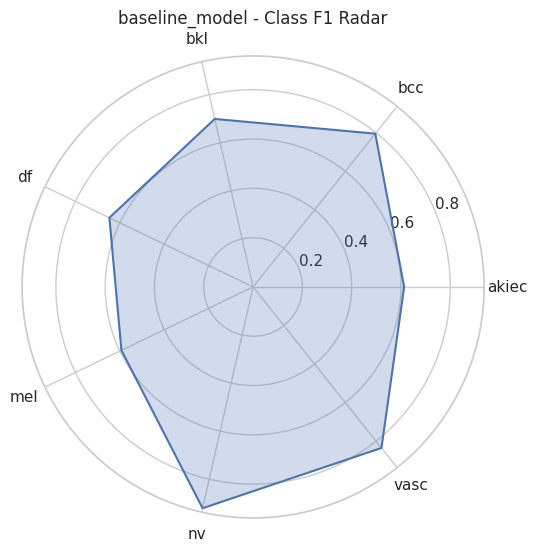

In [6]:
# radar chart

def plot_radar(model_name):
    row = df[df["model_name"] == model_name].iloc[0]

    classes = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
    values = [row[f"{cls}_f1"] for cls in classes]

    angles = np.linspace(0, 2*np.pi, len(classes), endpoint=False).tolist()
    values += values[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(classes)
    ax.set_title(f"{model_name} - Class F1 Radar")
    plt.show()

# Example:
plot_radar("baseline_model")